# EDA: продажи Superstore (США)

**Цель:** исследовать продажи, ассортимент и поведение клиентов супермаркета в США, выявить ключевые товары, категории, регионы и закономерности для продуктовой и коммерческой команды.

**Данные:** Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Segment, Region, City, State, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit.

## 1. Импорт библиотек и загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Стиль графиков: читаемые подписи и шкалы
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 50)

# Форматтер для больших чисел на осях (тыс., млн)
def thousands(x, pos):
    return f'{x/1e3:.0f}K'
def millions(x, pos):
    return f'{x/1e6:.1f}M'

FILE_PATH = 'Sample - Superstore.csv'
# Кодировка: utf-8 → cp1252 (Windows) → latin-1 (принимает любой байт)
for enc in ('utf-8', 'cp1252', 'latin-1'):
    try:
        df = pd.read_csv(FILE_PATH, encoding=enc)
        break
    except UnicodeDecodeError:
        continue
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 2. Подготовка данных

In [4]:
# Имена колонок в snake_case
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
print('Колонки:', df.columns.tolist())

Колонки: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [5]:
# Даты (формат M/D/YYYY в данных)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

# Числовые поля
for col in ['sales', 'quantity', 'discount', 'profit']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

dup = df.duplicated().sum()
print(f'Дубликатов строк: {dup}')
if dup > 0:
    df = df.drop_duplicates()

critical = [c for c in ['order_id', 'order_date', 'sales', 'category'] if c in df.columns]
df = df.dropna(subset=critical)
print(f'Строк после очистки: {len(df)}')
df.dtypes

Дубликатов строк: 0
Строк после очистки: 9994


row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub_category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

## 3. Базовые метрики

In [6]:
n_orders = df['order_id'].nunique()
n_customers = df['customer_id'].nunique()
date_min, date_max = df['order_date'].min(), df['order_date'].max()
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
avg_order_sales = df.groupby('order_id')['sales'].sum().mean()
neg_profit = (df['profit'] < 0).sum()

print(f'Уникальных заказов:     {n_orders:,}')
print(f'Уникальных клиентов:   {n_customers:,}')
print(f'Период:                {date_min.date()} — {date_max.date()}')
print(f'Суммарные продажи:     ${total_sales:,.2f}')
print(f'Суммарная прибыль:     ${total_profit:,.2f}')
print(f'Средний чек на заказ:  ${avg_order_sales:,.2f}')
print(f'Позиций с убытком:     {neg_profit:,}')

Уникальных заказов:     5,009
Уникальных клиентов:   793
Период:                2014-01-03 — 2017-12-30
Суммарные продажи:     $2,297,200.86
Суммарная прибыль:     $286,397.02
Средний чек на заказ:  $458.61
Позиций с убытком:     1,871


## 4. География: регионы, штаты, города

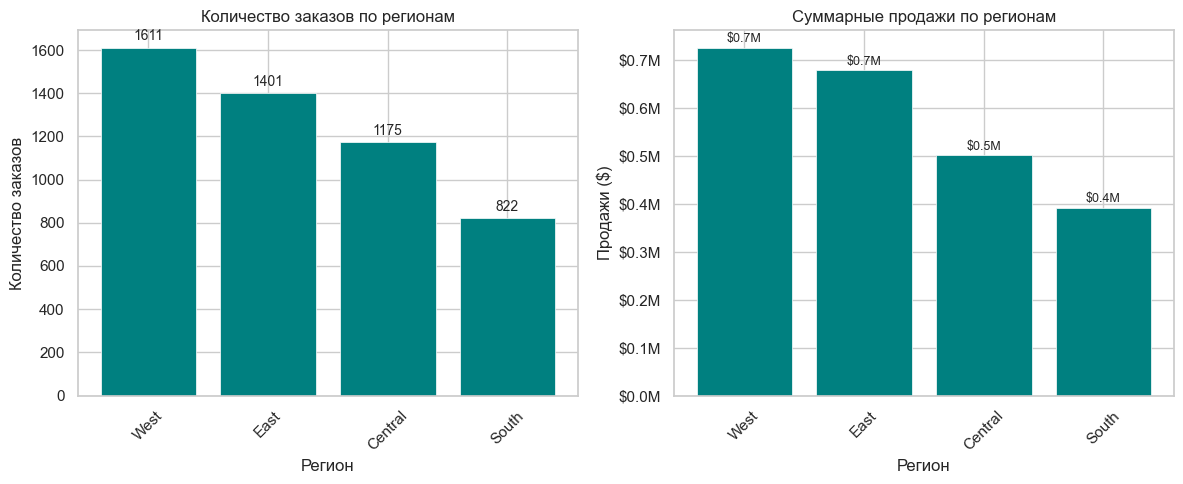

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

by_region_orders = df.groupby('region')['order_id'].nunique().sort_values(ascending=False)
bars0 = axes[0].bar(by_region_orders.index, by_region_orders.values, color='teal', edgecolor='white', linewidth=0.5)
axes[0].set_title('Количество заказов по регионам')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Количество заказов')
axes[0].tick_params(axis='x', rotation=45)
for b in bars0:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 20, int(b.get_height()), ha='center', va='bottom', fontsize=10)

by_region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
bars1 = axes[1].bar(by_region_sales.index, by_region_sales.values, color='teal', edgecolor='white', linewidth=0.5)
axes[1].set_title('Суммарные продажи по регионам')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Продажи ($)')
axes[1].tick_params(axis='x', rotation=45)
for b in bars1:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5000, f'${b.get_height()/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

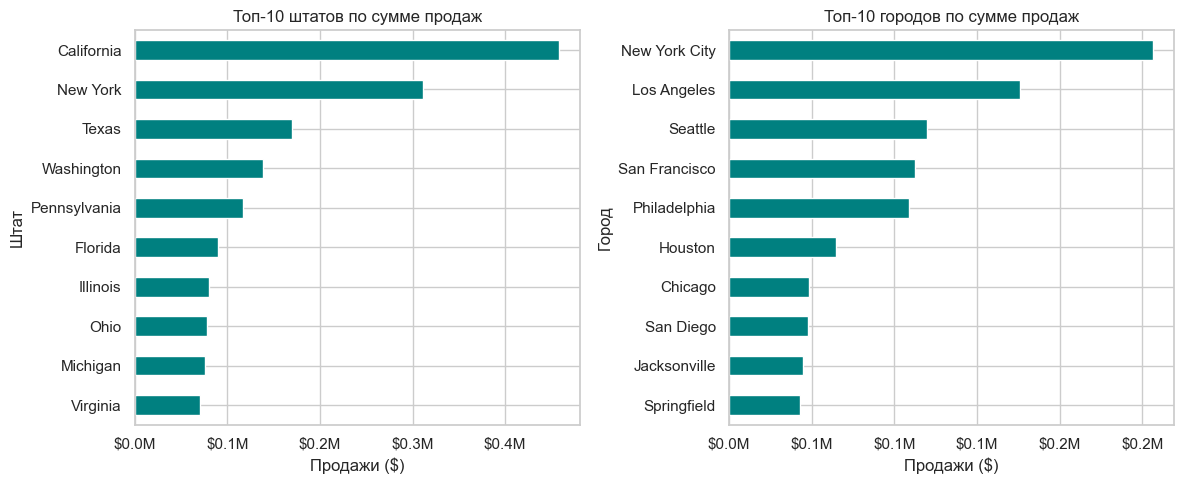

In [8]:
by_state = df.groupby('state')['sales'].sum().nlargest(10)
by_city = df.groupby('city')['sales'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax_formatter = FuncFormatter(lambda x, p: f'${x/1e6:.1f}M')

by_state.sort_values().plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].xaxis.set_major_formatter(ax_formatter)
axes[0].set_title('Топ-10 штатов по сумме продаж')
axes[0].set_xlabel('Продажи ($)')
axes[0].set_ylabel('Штат')

by_city.sort_values().plot(kind='barh', ax=axes[1], color='teal', edgecolor='white')
axes[1].xaxis.set_major_formatter(ax_formatter)
axes[1].set_title('Топ-10 городов по сумме продаж')
axes[1].set_xlabel('Продажи ($)')
axes[1].set_ylabel('Город')
plt.tight_layout()
plt.show()

## 5. Динамика заказов и выручки по месяцам

C:\Users\Виталий\AppData\Local\Temp\ipykernel_27760\2329521652.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  orders_monthly = orders_daily.resample('M').sum()
C:\Users\Виталий\AppData\Local\Temp\ipykernel_27760\2329521652.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_monthly = sales_daily.resample('M').sum()


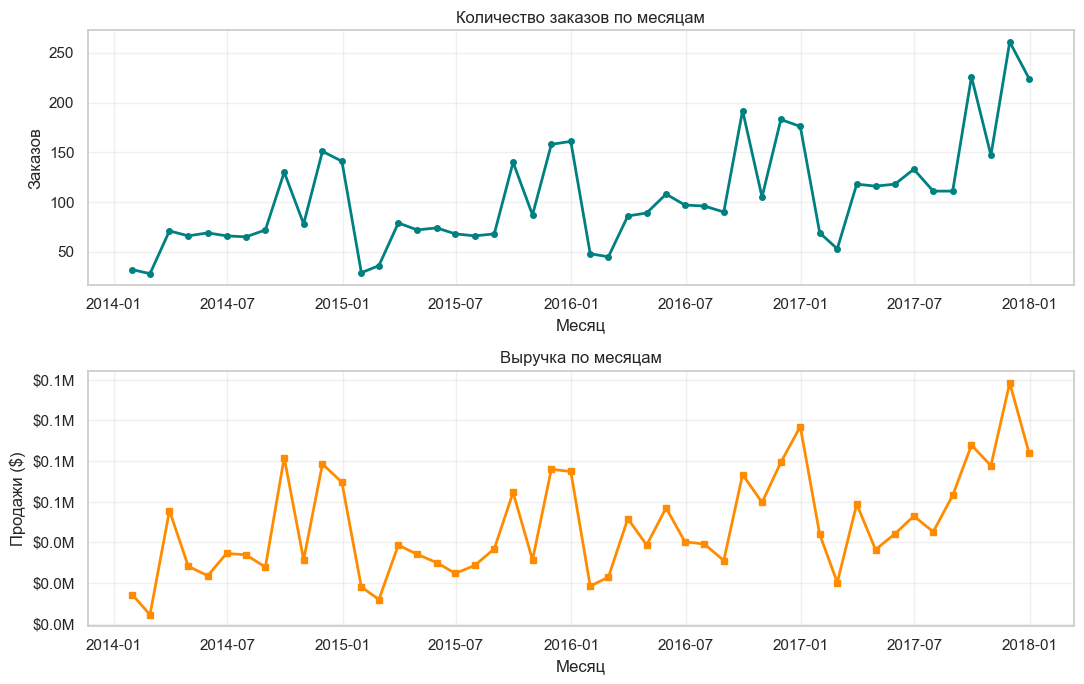

In [9]:
orders_daily = df.groupby('order_date')['order_id'].nunique()
orders_monthly = orders_daily.resample('M').sum()
sales_daily = df.groupby('order_date')['sales'].sum()
sales_monthly = sales_daily.resample('M').sum()

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(orders_monthly.index, orders_monthly.values, color='teal', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Количество заказов по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Заказов')
axes[0].grid(True, alpha=0.3)

axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].plot(sales_monthly.index, sales_monthly.values, color='darkorange', linewidth=2, marker='s', markersize=4)
axes[1].set_title('Выручка по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Продажи ($)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

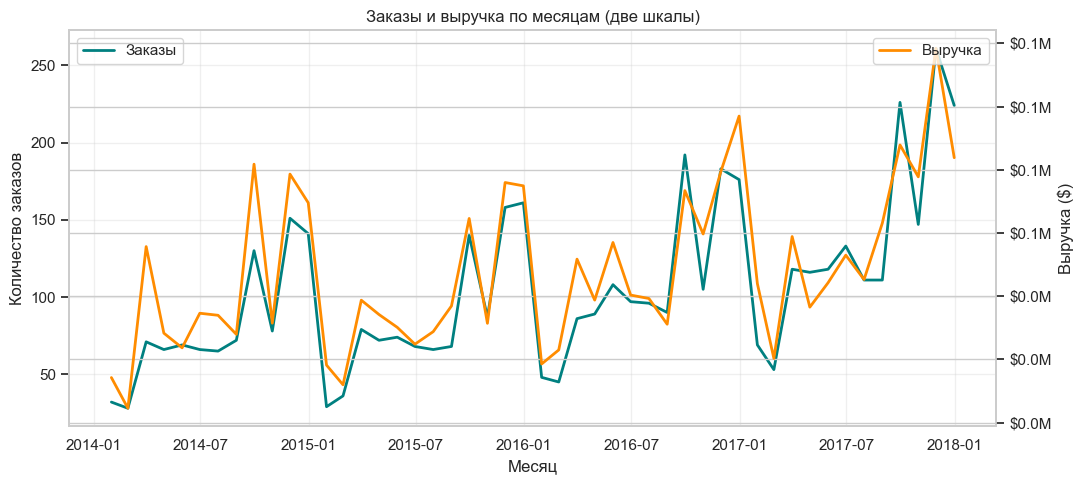

In [10]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(orders_monthly.index, orders_monthly.values, color='teal', linewidth=2, label='Заказы')
ax1.set_ylabel('Количество заказов', fontsize=12)
ax1.set_xlabel('Месяц', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax2.plot(sales_monthly.index, sales_monthly.values, color='darkorange', linewidth=2, label='Выручка')
ax2.set_ylabel('Выручка ($)', fontsize=12)
ax2.legend(loc='upper right')
plt.title('Заказы и выручка по месяцам (две шкалы)')
plt.tight_layout()
plt.show()

## 6. Категории и подкатегории товаров

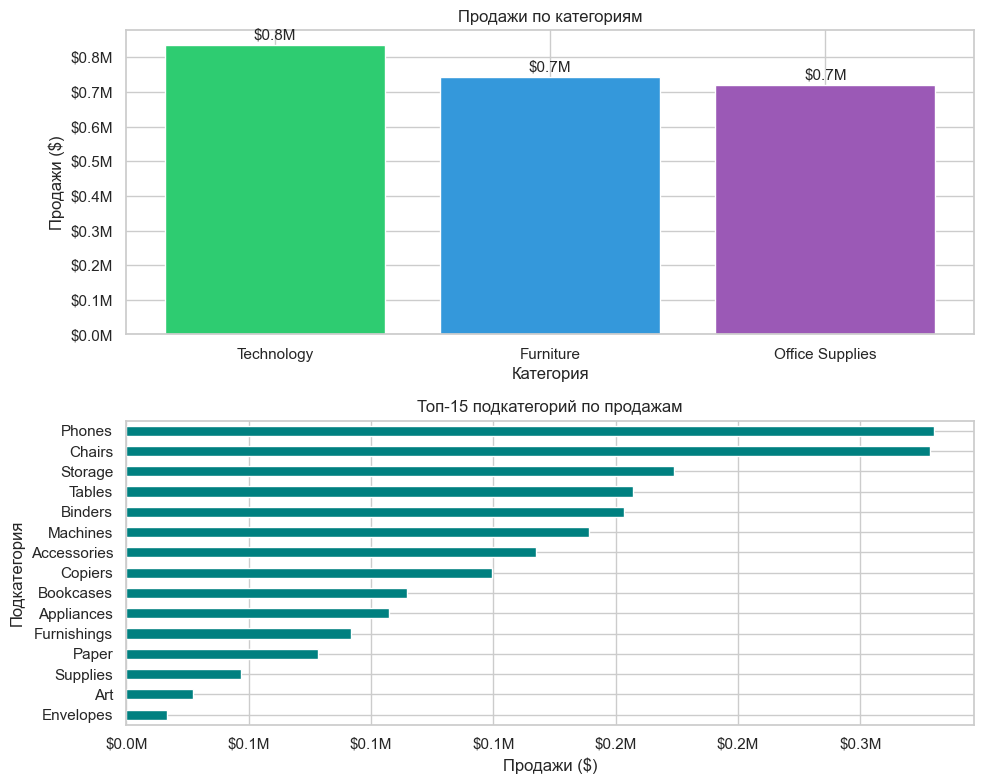

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

by_cat = df.groupby('category')['sales'].sum().sort_values(ascending=False)
bars = axes[0].bar(by_cat.index, by_cat.values, color=['#2ecc71', '#3498db', '#9b59b6'], edgecolor='white')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].set_title('Продажи по категориям')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Продажи ($)')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 8000, f'${b.get_height()/1e6:.1f}M', ha='center', va='bottom', fontsize=11)

by_sub = df.groupby('sub_category')['sales'].sum().nlargest(15).sort_values()
by_sub.plot(kind='barh', ax=axes[1], color='teal', edgecolor='white')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].set_title('Топ-15 подкатегорий по продажам')
axes[1].set_xlabel('Продажи ($)')
axes[1].set_ylabel('Подкатегория')
plt.tight_layout()
plt.show()

## 7. Популярные товары

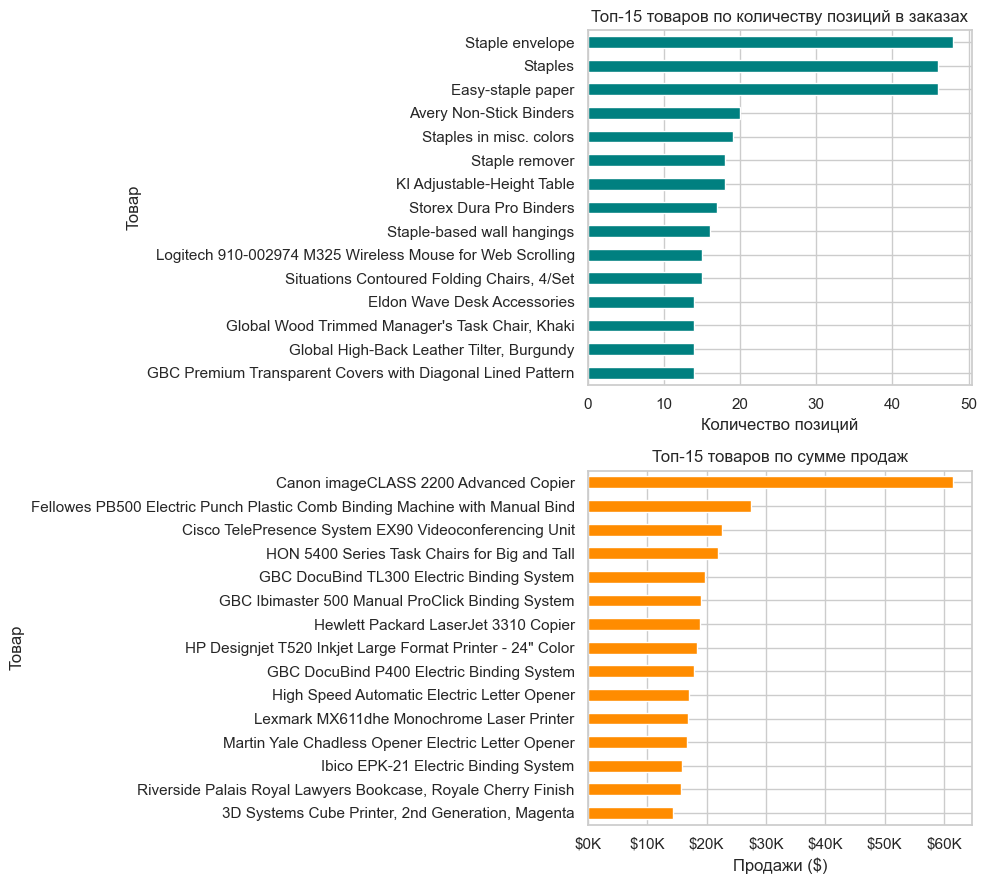

In [12]:
by_product_count = df.groupby('product_name').size().nlargest(15)
by_product_sales = df.groupby('product_name')['sales'].sum().nlargest(15)

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

by_product_count.sort_values().plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Топ-15 товаров по количеству позиций в заказах')
axes[0].set_xlabel('Количество позиций')
axes[0].set_ylabel('Товар')

by_product_sales.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))
axes[1].set_title('Топ-15 товаров по сумме продаж')
axes[1].set_xlabel('Продажи ($)')
axes[1].set_ylabel('Товар')
plt.tight_layout()
plt.show()

## 8. Доставка: Ship Mode и сроки

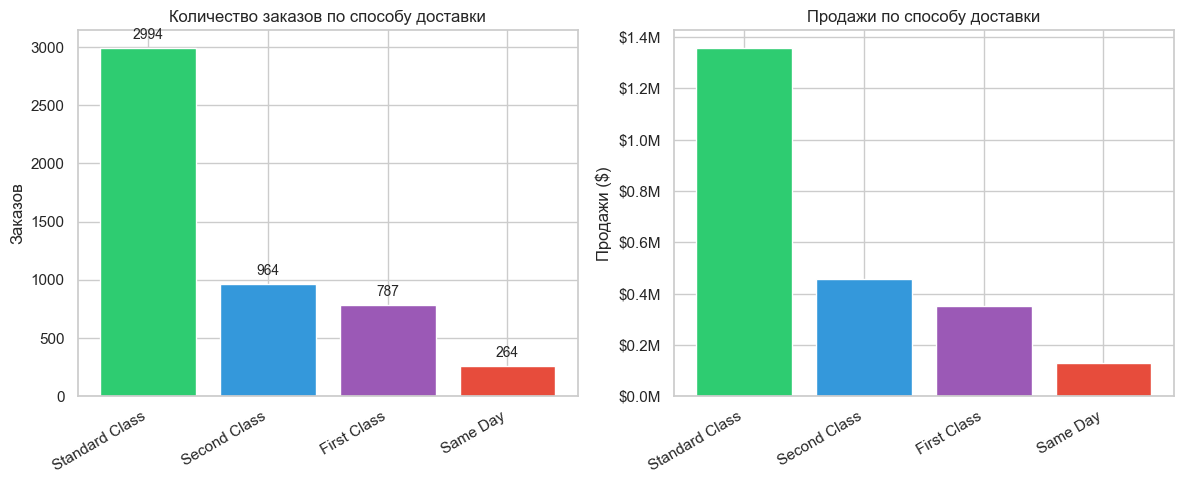

In [13]:
df['ship_days'] = (df['ship_date'] - df['order_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

by_mode_orders = df.groupby('ship_mode')['order_id'].nunique().sort_values(ascending=False)
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = axes[0].bar(range(len(by_mode_orders)), by_mode_orders.values, color=colors[:len(by_mode_orders)], edgecolor='white')
axes[0].set_xticks(range(len(by_mode_orders)))
axes[0].set_xticklabels(by_mode_orders.index, rotation=30, ha='right')
axes[0].set_title('Количество заказов по способу доставки')
axes[0].set_ylabel('Заказов')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 50, int(b.get_height()), ha='center', va='bottom', fontsize=10)

by_mode_sales = df.groupby('ship_mode')['sales'].sum().sort_values(ascending=False)
axes[1].bar(range(len(by_mode_sales)), by_mode_sales.values, color=colors[:len(by_mode_sales)], edgecolor='white')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].set_xticks(range(len(by_mode_sales)))
axes[1].set_xticklabels(by_mode_sales.index, rotation=30, ha='right')
axes[1].set_title('Продажи по способу доставки')
axes[1].set_ylabel('Продажи ($)')
plt.tight_layout()
plt.show()

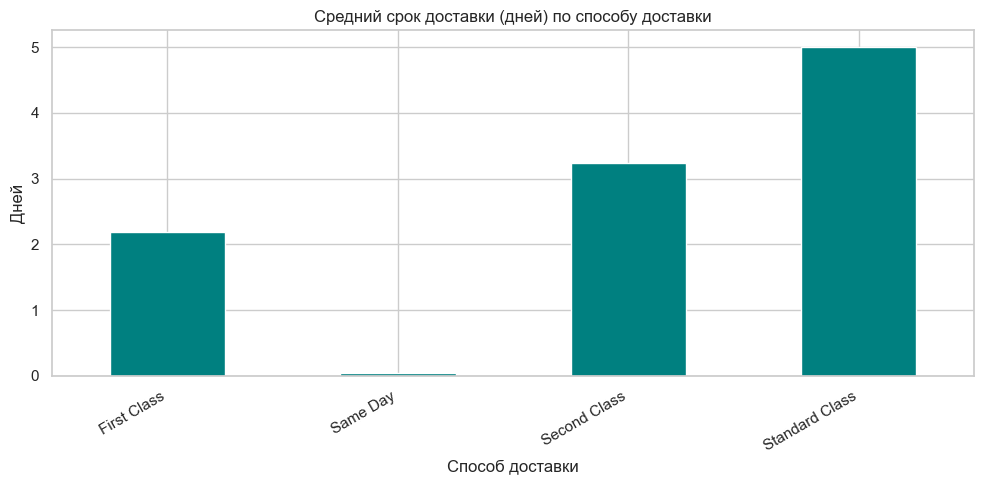

ship_mode
First Class       2.2
Same Day          0.0
Second Class      3.2
Standard Class    5.0


In [14]:
avg_days = df.groupby('ship_mode')['ship_days'].mean().sort_index()
avg_days.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Средний срок доставки (дней) по способу доставки')
plt.xlabel('Способ доставки')
plt.ylabel('Дней')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(avg_days.round(1).to_string())

## 9. Скидки и прибыль

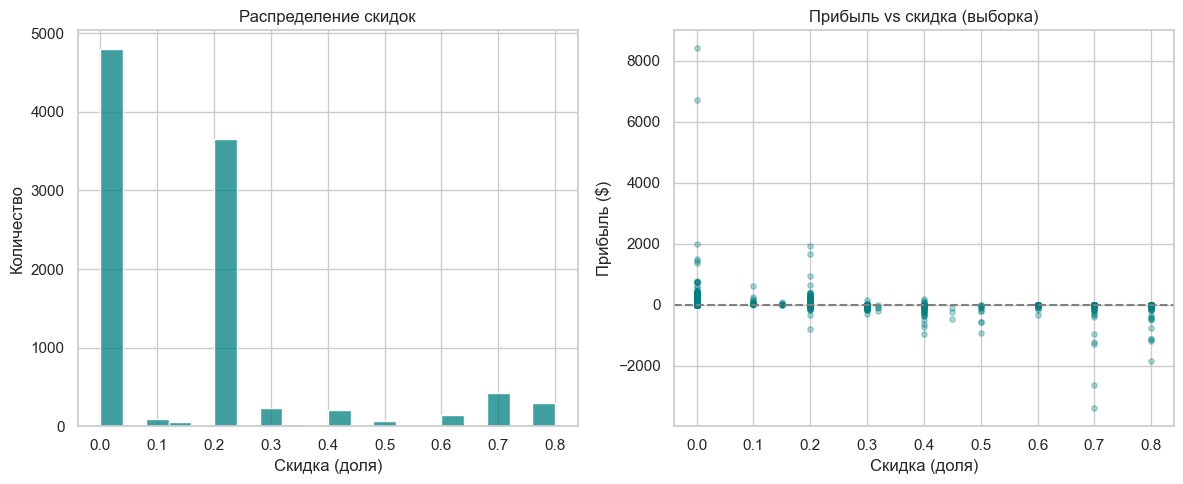

In [15]:
df['profit_margin'] = np.where(df['sales'] > 0, df['profit'] / df['sales'], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['discount'], bins=20, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Распределение скидок')
axes[0].set_xlabel('Скидка (доля)')
axes[0].set_ylabel('Количество')

sample = df.sample(min(2500, len(df)))
axes[1].scatter(sample['discount'], sample['profit'], alpha=0.3, s=15, c='teal')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Прибыль vs скидка (выборка)')
axes[1].set_xlabel('Скидка (доля)')
axes[1].set_ylabel('Прибыль ($)')
plt.tight_layout()
plt.show()

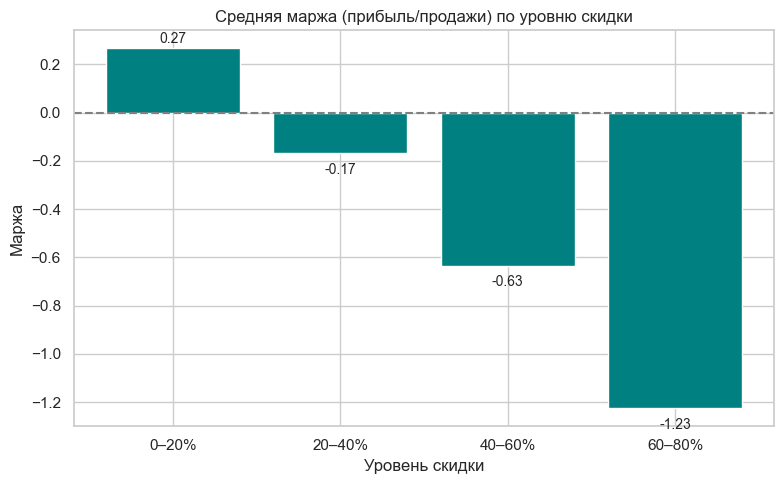

discount_bin
0–20%     0.2669
20–40%   -0.1669
40–60%   -0.6341
60–80%   -1.2252


In [16]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels = ['0–20%', '20–40%', '40–60%', '60–80%', '80%+']
df['discount_bin'] = pd.cut(df['discount'], bins=bins, labels=labels, include_lowest=True)
margin_by_discount = df.groupby('discount_bin', observed=True)['profit_margin'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(margin_by_discount.index.astype(str), margin_by_discount.values, color='teal', edgecolor='white')
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Средняя маржа (прибыль/продажи) по уровню скидки')
ax.set_xlabel('Уровень скидки')
ax.set_ylabel('Маржа')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01 if b.get_height() >= 0 else b.get_height() - 0.04, f'{b.get_height():.2f}', ha='center', va='bottom' if b.get_height() >= 0 else 'top', fontsize=10)
plt.tight_layout()
plt.show()
print(margin_by_discount.round(4).to_string())

## 10. Сегменты клиентов

In [17]:
seg_orders = df.groupby('segment')['order_id'].nunique()
seg_sales = df.groupby('segment')['sales'].sum()
seg_profit = df.groupby('segment')['profit'].sum()
seg_avg = df.groupby('segment')['sales'].mean()
seg_profit_avg = df.groupby('segment')['profit'].mean()

pd.DataFrame({
    'Заказов': seg_orders,
    'Продажи ($)': seg_sales.round(2),
    'Средний чек (поз.)': seg_avg.round(2),
    'Прибыль ($)': seg_profit.round(2),
    'Сред. прибыль на поз.': seg_profit_avg.round(2)
})

,Заказов,Продажи ($),Средний чек (поз.),Прибыль ($),Сред. прибыль на поз.
segment,,,,,
Consumer,2586,1161401.34,223.73,134119.21,25.84
Corporate,1514,706146.37,233.82,91979.13,30.46
Home Office,909,429653.15,240.97,60298.68,33.82


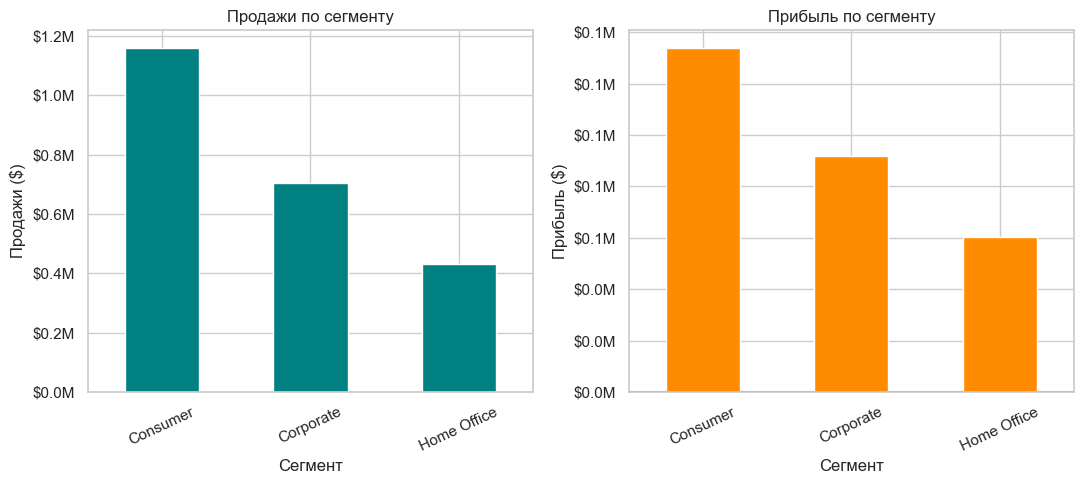

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

seg_sales.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].set_title('Продажи по сегменту')
axes[0].set_xlabel('Сегмент')
axes[0].set_ylabel('Продажи ($)')
axes[0].tick_params(axis='x', rotation=25)

seg_profit.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].axhline(0, color='gray', linestyle='-')
axes[1].set_title('Прибыль по сегменту')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Прибыль ($)')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 11. Кросс-анализ: регион × категория, регион × сегмент

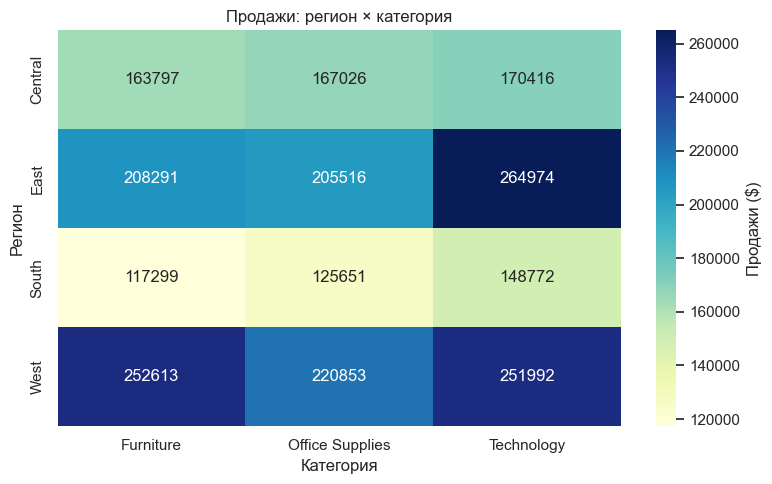

In [19]:
cross_rc = pd.crosstab(df['region'], df['category'], values=df['sales'], aggfunc='sum')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross_rc, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Продажи ($)'})
ax.set_title('Продажи: регион × категория')
ax.set_xlabel('Категория')
ax.set_ylabel('Регион')
plt.tight_layout()
plt.show()

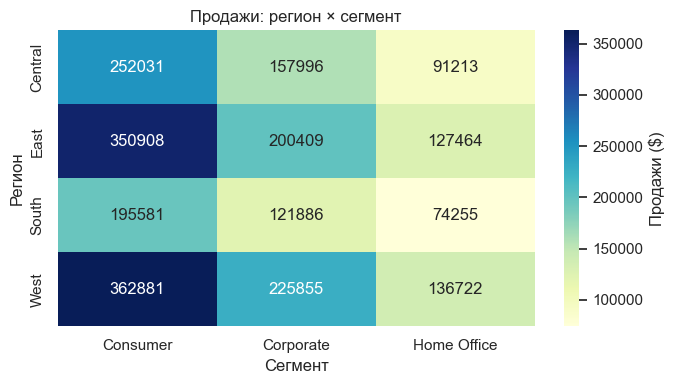

In [20]:
cross_rs = pd.crosstab(df['region'], df['segment'], values=df['sales'], aggfunc='sum')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(cross_rs, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Продажи ($)'})
ax.set_title('Продажи: регион × сегмент')
ax.set_xlabel('Сегмент')
ax.set_ylabel('Регион')
plt.tight_layout()
plt.show()

## 12. Итоговые выводы и рекомендации

- **Объём:** число заказов, клиентов, период; суммарная выручка и прибыль; позиции с убытком — зона внимания.
- **География:** ключевые регионы, штаты и города по продажам — приоритеты для логистики и маркетинга.
- **Ассортимент:** лидирующие категории и подкатегории; топ товары по частоте и по выручке (часто разные списки).
- **Доставка:** доминирующие Ship Mode; связь с выручкой и средние сроки доставки.
- **Скидки:** при высоких скидках маржа падает; уровни с отрицательной маржой — кандидаты на пересмотр политики.
- **Сегменты:** наиболее выгодные сегменты и комбинации регион × сегмент для таргета.
- **Рекомендации:** приоритизировать регионы и категории с высокой выручкой/маржой; пересмотреть скидки на убыточных уровнях; развивать прибыльные сегменты; при необходимости — ABC-анализ, анализ корзины, A/B по скидкам.